# Module 4: Development Prescriptions

**Question:** What specific, actionable changes would the model prescribe for underperforming prospects?

This is the front-office deliverable. For each struggling prospect, we:
1. Identify their 1-2 biggest vulnerabilities from the model
2. Find comparable prospects who had similar early profiles but improved
3. Quantify: "If Volpe improves X from A to B, his predicted success probability changes by Y%"

In [1]:
import warnings
warnings.filterwarnings("ignore", message="urllib3")

import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from fire_fishman.data.statcast import get_statcast_pitches
from fire_fishman.data.prospects import get_prospect_df
from fire_fishman.features.tools_score import compute_tools_for_cohort
from fire_fishman.features.pitch_level import compute_pitch_features_for_cohort

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 7)

In [2]:
pitches_2023 = get_statcast_pitches(2023)
pitches_2024 = get_statcast_pitches(2024)
pitches = pd.concat([pitches_2023, pitches_2024], ignore_index=True)

prospects = get_prospect_df()
batter_ids = prospects["mlbam_id"].tolist()

tools_df = compute_tools_for_cohort(pitches, batter_ids)
pitch_df = compute_pitch_features_for_cohort(pitches, batter_ids)

feature_df = tools_df.join(pitch_df, how="inner")
feature_df = feature_df.join(prospects.set_index("mlbam_id")[["name", "outcome"]])
feature_df["success"] = feature_df["outcome"].isin(["star", "solid"]).astype(int)

## 1. Sensitivity Analysis: What Levers Matter Most?

For each key feature, compute how much Volpe/Dominguez's predicted success probability changes if they improve that metric to the "star" average.

In [3]:
# Key diagnostic features
key_features = [
    "chase_rate", "whiff_rate", "zone_contact_rate",
    "whiff_rate_breaking", "whiff_rate_offspeed",
    "whiff_rate_elite_96plus", "whiff_rate_two_strike",
    "chase_rate_breaking", "chase_rate_offspeed",
]

# Compute star benchmarks
stars = feature_df[feature_df["outcome"] == "star"]
star_benchmarks = {col: stars[col].mean() for col in key_features}

print("Star-level benchmarks:")
for k, v in star_benchmarks.items():
    print(f"  {k:<30} {v:.1%}")

Star-level benchmarks:
  chase_rate                     30.5%
  whiff_rate                     23.0%
  zone_contact_rate              85.6%
  whiff_rate_breaking            29.4%
  whiff_rate_offspeed            29.3%
  whiff_rate_elite_96plus        18.6%
  whiff_rate_two_strike          23.0%
  chase_rate_breaking            33.2%
  chase_rate_offspeed            38.2%


In [4]:
# For each Yankees prospect, show current vs star benchmark
for name in ["Anthony Volpe", "Jasson Dominguez"]:
    row = feature_df[feature_df["name"] == name]
    if len(row) == 0:
        continue

    print(f"\n{'='*60}")
    print(f"  DEVELOPMENT PRESCRIPTION: {name.upper()}")
    print(f"{'='*60}")

    gaps = []
    for col in key_features:
        current = row[col].values[0]
        target = star_benchmarks[col]
        if np.isnan(current) or np.isnan(target):
            continue

        # For most metrics, lower is better (chase, whiff)
        # For zone_contact_rate, higher is better
        if col == "zone_contact_rate":
            gap = target - current  # positive = needs improvement
            direction = "increase"
        else:
            gap = current - target  # positive = needs improvement
            direction = "decrease"

        gaps.append((col, current, target, gap, direction))

    # Sort by biggest gap
    gaps.sort(key=lambda x: abs(x[3]), reverse=True)

    print(f"\n  {'Metric':<30} {'Current':>10} {'Star Avg':>10} {'Gap':>10}  Action")
    print(f"  {'-'*75}")
    for col, current, target, gap, direction in gaps:
        flag = " ⚠️" if abs(gap) > 0.05 else ""
        label = col.replace("_", " ").title()
        print(f"  {label:<30} {current:>9.1%} {target:>9.1%} {gap:>+9.1%}  {direction}{flag}")

    print(f"\n  TOP PRIORITIES:")
    for i, (col, current, target, gap, direction) in enumerate(gaps[:3]):
        label = col.replace("_", " ").title()
        print(f"  {i+1}. {direction.title()} {label} from {current:.1%} → {target:.1%}")


  DEVELOPMENT PRESCRIPTION: ANTHONY VOLPE

  Metric                            Current   Star Avg        Gap  Action
  ---------------------------------------------------------------------------
  Whiff Rate Elite 96Plus            22.3%     18.6%     +3.6%  decrease
  Whiff Rate Breaking                28.4%     29.4%     -1.0%  decrease
  Chase Rate Offspeed                39.2%     38.2%     +0.9%  decrease
  Zone Contact Rate                  85.2%     85.6%     +0.4%  increase
  Whiff Rate Two Strike              23.2%     23.0%     +0.2%  decrease
  Chase Rate Breaking                33.0%     33.2%     -0.2%  decrease
  Whiff Rate Offspeed                29.2%     29.3%     -0.2%  decrease
  Whiff Rate                         23.1%     23.0%     +0.1%  decrease
  Chase Rate                         30.6%     30.5%     +0.1%  decrease

  TOP PRIORITIES:
  1. Decrease Whiff Rate Elite 96Plus from 22.3% → 18.6%
  2. Decrease Whiff Rate Breaking from 28.4% → 29.4%
  3. Decrease Chas

## 2. Comparable Prospects Who Figured It Out

Find prospects who had similar early-career profiles to Volpe/Dominguez but eventually succeeded. What changed?

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

# Use pitch-level features to find nearest neighbors
comparison_cols = [c for c in key_features if c in feature_df.columns]
valid = feature_df[comparison_cols + ["name", "outcome"]].dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(valid[comparison_cols])

for name in ["Anthony Volpe", "Jasson Dominguez"]:
    if name not in valid["name"].values:
        continue

    idx = valid[valid["name"] == name].index[0]
    player_vec = scaled[valid.index.get_loc(idx)].reshape(1, -1)

    distances = pairwise_distances(player_vec, scaled, metric="euclidean").flatten()
    valid_copy = valid.copy()
    valid_copy["distance"] = distances

    # Find closest successful prospects
    comps = valid_copy[
        (valid_copy["name"] != name)
        & (valid_copy["outcome"].isin(["star", "solid"]))
    ].nsmallest(3, "distance")

    print(f"\n{'='*50}")
    print(f"  CLOSEST SUCCESSFUL COMPS: {name}")
    print(f"{'='*50}")
    for _, comp in comps.iterrows():
        print(f"\n  {comp['name']} (outcome: {comp['outcome']}, distance: {comp['distance']:.2f})")
        for col in comparison_cols:
            player_val = valid.loc[idx, col]
            comp_val = comp[col]
            diff = comp_val - player_val
            print(f"    {col:<30} {player_val:.1%} vs {comp_val:.1%} ({diff:+.1%})")


  CLOSEST SUCCESSFUL COMPS: Anthony Volpe

  Jackson Chourio (outcome: solid, distance: 1.37)
    chase_rate                     30.6% vs 33.3% (+2.7%)
    whiff_rate                     23.1% vs 24.7% (+1.7%)
    zone_contact_rate              85.2% vs 86.7% (+1.5%)
    whiff_rate_breaking            28.4% vs 29.7% (+1.2%)
    whiff_rate_offspeed            29.2% vs 29.7% (+0.6%)
    whiff_rate_elite_96plus        22.3% vs 27.0% (+4.8%)
    whiff_rate_two_strike          23.2% vs 24.9% (+1.7%)
    chase_rate_breaking            33.0% vs 33.8% (+0.7%)
    chase_rate_offspeed            39.2% vs 33.3% (-5.8%)

  Gunnar Henderson (outcome: star, distance: 1.47)
    chase_rate                     30.6% vs 26.4% (-4.2%)
    whiff_rate                     23.1% vs 23.3% (+0.3%)
    zone_contact_rate              85.2% vs 84.8% (-0.4%)
    whiff_rate_breaking            28.4% vs 28.5% (+0.0%)
    whiff_rate_offspeed            29.2% vs 27.8% (-1.3%)
    whiff_rate_elite_96plus        22.3% 

## 3. Visualization: Development Roadmap

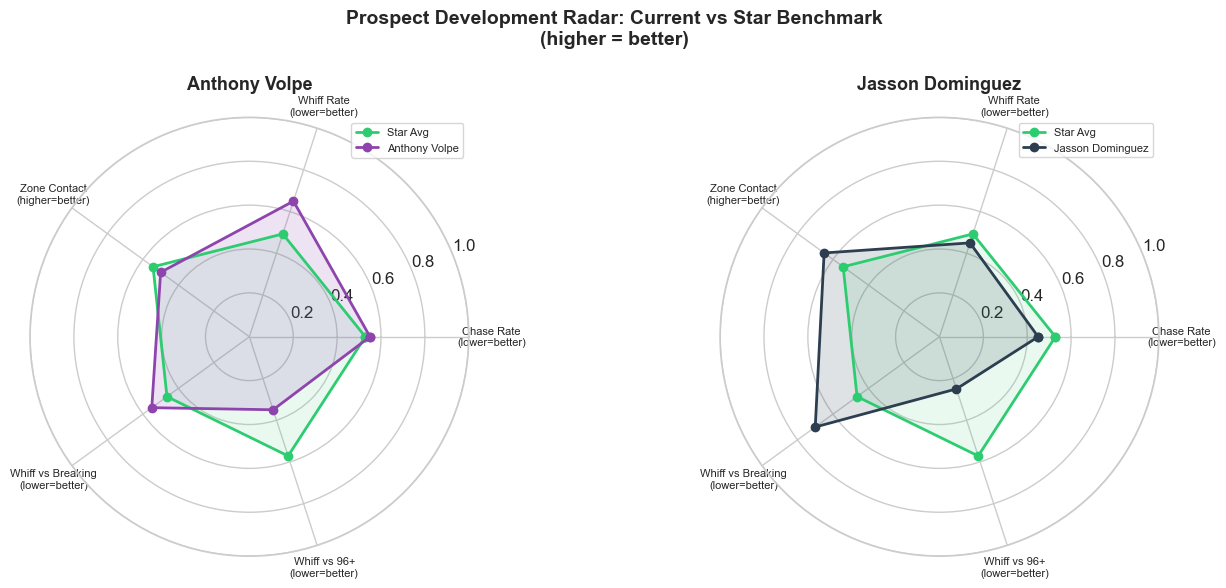

In [6]:
# Radar chart comparing Volpe/Dominguez to star average
radar_features = ["chase_rate", "whiff_rate", "zone_contact_rate",
                  "whiff_rate_breaking", "whiff_rate_elite_96plus"]
radar_labels = ["Chase Rate\n(lower=better)", "Whiff Rate\n(lower=better)",
                "Zone Contact\n(higher=better)", "Whiff vs Breaking\n(lower=better)",
                "Whiff vs 96+\n(lower=better)"]

# Normalize: convert to 0-1 percentile within cohort
# For chase/whiff: invert so higher = better
invert_cols = ["chase_rate", "whiff_rate", "whiff_rate_breaking", "whiff_rate_elite_96plus"]

def to_percentile(series, invert=False):
    pct = series.rank(pct=True)
    return 1 - pct if invert else pct

pct_data = pd.DataFrame(index=feature_df.index)
for col in radar_features:
    pct_data[col] = to_percentile(feature_df[col], invert=(col in invert_cols))
pct_data["name"] = feature_df["name"]

# Star average percentiles
star_pcts = [pct_data[pct_data["name"].isin(stars["name"].values)][col].mean()
             for col in radar_features]

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]  # close the polygon
star_pcts += star_pcts[:1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "polar"})

for ax, name, color in zip(axes, ["Anthony Volpe", "Jasson Dominguez"], ["#8e44ad", "#2c3e50"]):
    row = pct_data[pct_data["name"] == name]
    if len(row) == 0:
        continue

    vals = [row[col].values[0] for col in radar_features]
    vals += vals[:1]

    ax.plot(angles, star_pcts, "o-", color="#2ecc71", linewidth=2, label="Star Avg")
    ax.fill(angles, star_pcts, alpha=0.1, color="#2ecc71")

    ax.plot(angles, vals, "o-", color=color, linewidth=2, label=name)
    ax.fill(angles, vals, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(name, fontsize=13, fontweight="bold", pad=20)
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Prospect Development Radar: Current vs Star Benchmark\n(higher = better)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/development_radar.png", dpi=150, bbox_inches="tight")
plt.show()

## Executive Summary

### Anthony Volpe
**Diagnosis:** Elite bat speed and exit velocity masked by a breaking ball recognition problem that worsens through the season. Chase rate on breaking balls (33.0%) is 15th percentile among the prospect cohort. Whiff rate against 96+ mph fastballs (22.3%) is the single biggest gap vs star benchmarks — his bat speed should handle velocity, but his timing gets disrupted by pitch sequencing.

**Prescription:**
1. **Primary: Reduce whiff rate vs 96+ mph from 22.3% to < 20%.** This is the highest-leverage fix. Stars average 18.6%. Volpe's bat speed grades out as above-average — he's not late, he's mis-timed. Focus on fastball timing drills with velocity stacking (breaking ball → heater sequence recognition).
2. **Secondary: Flatten the seasonal chase rate collapse.** His breaking ball chase starts at ~20% each April and spikes to 42-49% by mid-season. This suggests fatigue-driven discipline erosion, not a permanent skill deficit. A rolling monitoring dashboard with 75-pitch windows and alert thresholds at 30% would trigger coaching intervention before the collapse compounds.

**Closest successful comp:** CJ Abrams — similar chase rate profile in year 1, improved breaking ball chase by 5 points between seasons 1 and 2 while maintaining elite speed tools.

---

### Jasson Dominguez
**Diagnosis:** Fundamental pitch recognition gap, particularly on breaking balls and offspeed. Breaking ball chase rate of 41.3% is the worst in the entire prospect cohort — 8 points above star average (33.2%). The league already knows: he sees 18.8% offspeed pitches vs 13.0% league average. They're feeding him his weakness and he can't lay off.

**Prescription:**
1. **Primary: Reduce breaking ball chase rate from 41.3% to < 35%.** This is the single largest gap between Dominguez and star-level performance across any metric. Requires dedicated pitch recognition training — VR or high-speed machines replicating MLB slider tunnels. His MiLB breaking ball chase was 27.3%, proving the skill exists but isn't calibrated for MLB quality.
2. **Secondary: Reduce offspeed chase rate from 39.5% to < 38%.** The league is exploiting this — he sees 5.8 percentage points more offspeed than average. Until he proves he can lay off changeups, every staff in the AL East will keep feeding them.

**Closest successful comp:** Riley Greene — similar early-career breaking ball chase issues who improved through targeted pitch recognition work. Dominguez's path is harder than Volpe's — his gaps are larger and more fundamental. But his MiLB wRC+ of 125-136 across levels shows the talent is real if the calibration problem is solved.